<a href="https://colab.research.google.com/github/prachityagi992/Bank_Customer_Churn_Analysis/blob/main/Copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
BARCLAYS BANKS CHURN ANALYSIS

### PROJECT OBJECTIVE
 ----Barclays bank facing high customer churns rate , and customer not keep using services , being a
     Data Scientist your task is to identify the companies so that thety can get the real time insights and management
     can take decision accordingly , previously banks were not getting timely insights and did not take decision
     timely , that costs high customer churn rate  , the previous methodologies were old and not upto dated presently bank
     need live analysis and corrective measures to predict the furture churn rates and live analysis

    

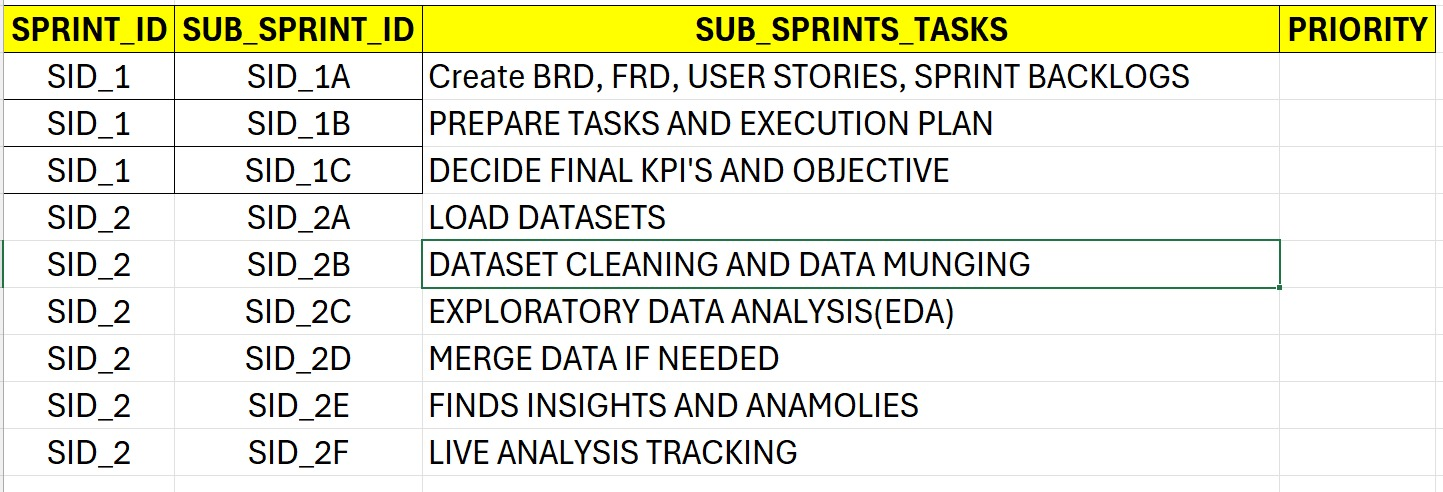

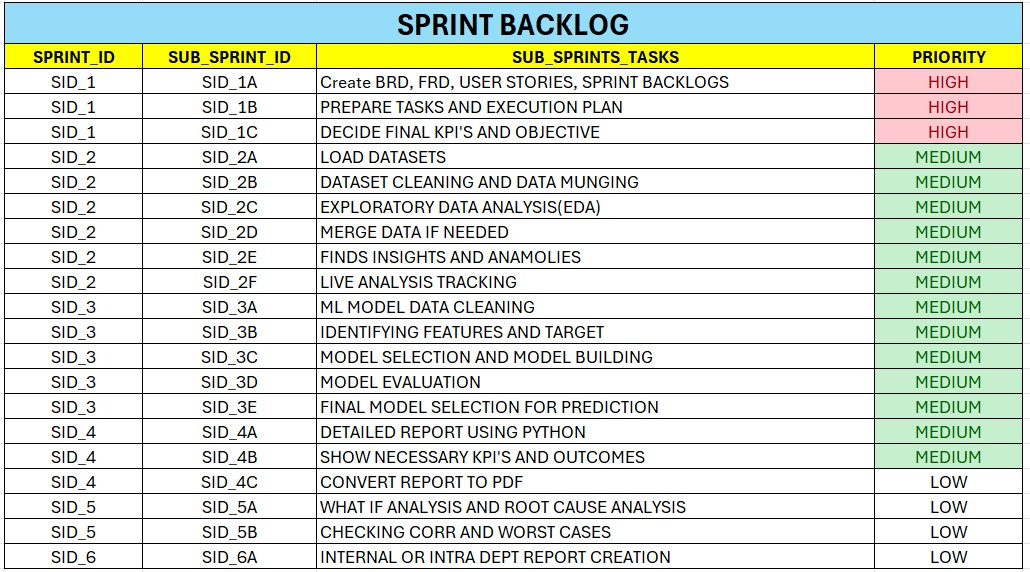

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, recall_score

import pickle
import IPython as ip

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier

import warnings
warnings.filterwarnings('ignore')

print("All Modules Loaded Successfully!!")

All Modules Loaded Successfully!!


STEP 2 = LOAD DATASET

In [ ]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ActiveCustomer.xlsx"
active_customer_df= pd.read_excel(url)
print("Done")

Done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CreditCard.xlsx"
credit_card_df = pd.read_excel(url)
print("Done")


Done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/ExitCustomer.xlsx"
exit_customer_df = pd.read_excel(url)
print("Done")

Done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Gender.xlsx"
gender_df = pd.read_excel(url)
print("Done")

Done


In [ ]:
url = "https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Geography.xlsx"
geography_df = pd.read_excel(url)
print("Done")

Done


In [ ]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/Bank_Churn.csv"
bank_churn_df= pd.read_csv(url)
print("Done")

Done


In [ ]:
url="https://github.com/ankitmisk/PowerBI-Dataset/raw/refs/heads/main/BARCLAYS%20CUSTOMER%20CHURN%20ANALYSIS%20POWERBI%20REPORT/Datasets/CustomerInfo.csv"
customer_info_df= pd.read_csv(url)
print("Done")

Done


In [ ]:
all_dfs = [active_customer_df,
           credit_card_df,
           exit_customer_df,
           gender_df,
           geography_df,
           bank_churn_df,
           customer_info_df]

for i in all_dfs:
    print('=' * 50)
    display(i.sample(2))

,ActiveID,ActiveCategory
1,0,Inactive Member
0,1,Active Member


,CreditID,Category
1,0,non credit card holder
0,1,credit card holder


,ExitID,ExitCategory
0,1,Exit
1,0,Retain


,GenderID,GenderCategory
0,1,Male
1,2,Female


,GeographyID,GeographyLocation
0,1,France
1,2,Spain


,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
3526,3527,15795129,799,1,2,30,6,0.00,2,1,0,136827.96,0,08-09-2017
485,486,15637954,730,1,2,35,3,155470.55,1,1,1,53718.28,0,05-11-2019


,CustomerId,Surname
4547,15672152,Grant
67,15641582,Chibugo


In [ ]:
# Step 3.1: Show bank_churn_df sample
bank_churn_df.sample(5)

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ
5564,5565,15700083,609,2,1,39,6,139443.75,2,1,0,9234.06,0,04-09-2017
2854,2855,15646609,748,1,1,33,4,142645.43,1,0,0,69132.66,0,15-03-2019
8730,8731,15634373,764,1,1,30,6,0.00,2,0,1,105155.66,0,04-07-2017
6550,6551,15617331,637,3,2,39,5,109698.41,1,1,1,88391.29,1,13-11-2017
472,473,15635367,774,1,1,26,6,93844.69,1,1,0,28415.36,0,02-12-2016


In [ ]:
# Step 3.2: Show df shape size
bank_churn_df.shape

# 14 columns and 10k rows


(10000, 14)

In [ ]:
bank_churn_df.size

140000

In [ ]:
# Combine all dfs
merged_df = pd.merge(bank_churn_df, customer_info_df, on='CustomerId')
merged_df = pd.merge(merged_df, geography_df, on='GeographyID')
final_df = pd.merge(merged_df, gender_df, on='GenderID')
final_df

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory
0,1,15634602,619,1,2,42,7,0.00,1,1,1,101348.88,1,23-03-2016,Hargrave,France,Female
1,2,15647311,608,2,2,41,4,83807.86,1,0,1,112542.58,0,09-10-2018,Hill,Spain,Female
2,3,15619304,502,1,2,42,4,159660.80,3,1,0,113931.57,1,25-03-2019,Onio,France,Female
3,4,15701354,699,1,2,39,3,0.00,2,0,0,93826.63,0,24-10-2019,Boni,France,Female
4,5,15737888,850,2,2,43,3,125510.82,1,1,1,79084.10,0,22-11-2019,Mitchell,Spain,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,1,1,39,5,0.00,2,1,0,96270.64,0,25-03-2018,Obijiaku,France,Male
9996,9997,15569892,516,1,1,35,5,57369.61,1,1,1,101699.77,0,17-06-2018,Johnstone,France,Male
9997,9998,15584532,709,1,2,36,5,0.00,1,0,1,42085.58,1,18-03-2018,Liu,France,Female
9998,9999,15682355,772,3,1,42,3,75075.31,2,1,0,92888.52,1,12-11-2019,Sabbatini,Germany,Male


In [ ]:
final_df.shape

(10000, 17)

In [ ]:
# show column info
# step 3.4
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [ ]:
# show column info
# step 3.4
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   RowNumber          10000 non-null  int64  
 1   CustomerId         10000 non-null  int64  
 2   CreditScore        10000 non-null  int64  
 3   GeographyID        10000 non-null  int64  
 4   GenderID           10000 non-null  int64  
 5   Age                10000 non-null  int64  
 6   Tenure             10000 non-null  int64  
 7   Balance            10000 non-null  float64
 8   NumOfProducts      10000 non-null  int64  
 9   HasCrCard          10000 non-null  int64  
 10  IsActiveMember     10000 non-null  int64  
 11  EstimatedSalary    10000 non-null  float64
 12  Exited             10000 non-null  int64  
 13  Bank DOJ           10000 non-null  object 
 14  Surname            10000 non-null  object 
 15  GeographyLocation  10000 non-null  object 
 16  GenderCategory     1000

In [ ]:
# Step 3.5: Drop Nan or missing values
final_df.dropna(inplace=True)
print("Done")

Done


In [ ]:
# step 3.5: Drop nan or missing values
final_df.dropna(inplace=True)
print("Done")

Done


In [ ]:
# step 3.6 Show data stats
final_df.describe(include = 'number')

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,1.749500,1.454300,38.921800,4.86430,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,0.830433,0.497932,10.487806,1.21525,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,1.000000,1.000000,18.000000,3.00000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,1.000000,1.000000,32.000000,4.00000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,1.000000,1.000000,37.000000,5.00000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,3.000000,2.000000,44.000000,6.00000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,3.000000,2.000000,92.000000,7.00000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# step 3.8: Show Data correlation
corr = final_df.corr(numeric_only=True)
corr

# corr range form
# -1 to +1
# -1: represents: Highly -negative correlation
# +1: represents: Highly +positive correlation
# 0: represents: no correlation

,RowNumber,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,-0.005196,-0.018196,0.000783,0.002901,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.000821,0.002641,0.009497,0.003884,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,0.008267,0.002857,-0.003965,-0.007355,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
GeographyID,-0.005196,0.000821,0.008267,1.000000,0.016936,0.048092,-0.003858,0.348700,-0.006180,0.004036,-0.012692,0.007382,0.153771
GenderID,-0.018196,0.002641,0.002857,0.016936,1.000000,0.027544,-0.008018,-0.012087,0.021859,-0.005766,-0.022544,0.008112,0.106512
Age,0.000783,0.009497,-0.003965,0.048092,0.027544,1.000000,0.010788,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.002901,0.003884,-0.007355,-0.003858,-0.008018,0.010788,1.000000,0.001457,-0.029927,0.003857,-0.007576,0.005744,0.000699
Balance,-0.009067,-0.012419,0.006268,0.348700,-0.012087,0.028308,0.001457,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.006180,0.021859,-0.030680,-0.029927,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,0.004036,-0.005766,-0.011721,0.003857,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138


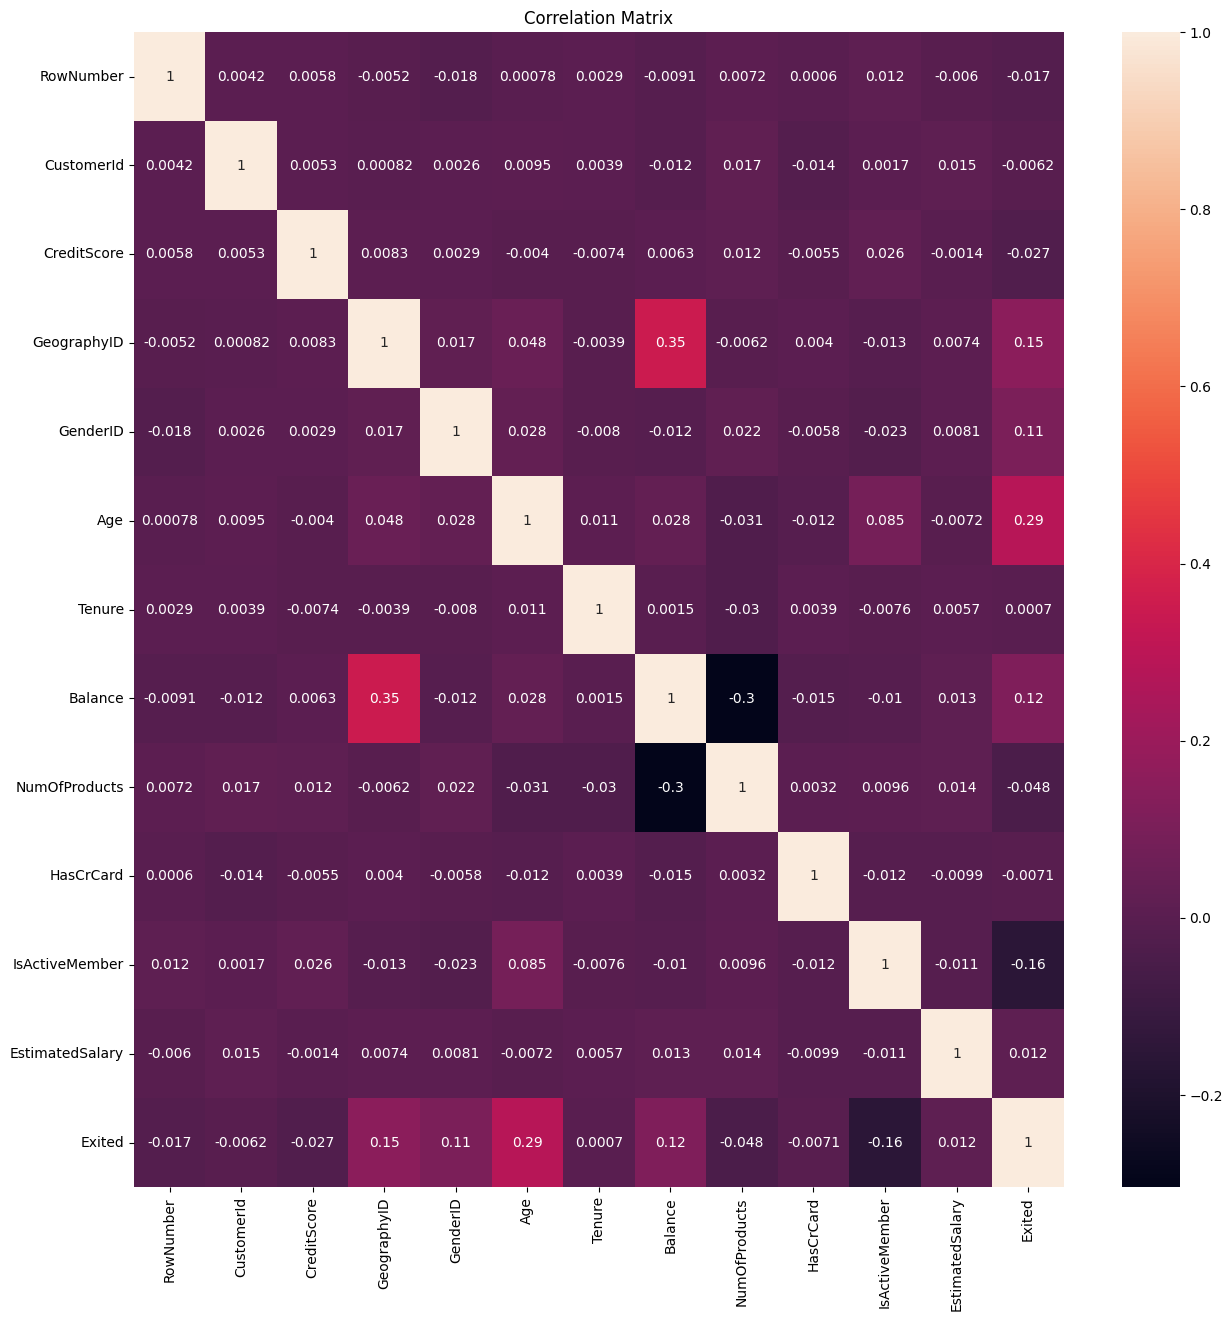

In [ ]:
# Step 3.9
plt.figure(figsize=(15,15))
plt.title("Correlation Matrix")
sns.heatmap(corr, annot=True)
plt.show()

In [ ]:
# Step 3.10 Divide Columns into required objects

textual_columns = final_df.select_dtypes('object').columns
numerical_columns = final_df.select_dtypes('number').columns

print("textual Columns: \n", textual_columns)
print('='*100)
print("Numerical Columns: \n", numerical_columns)

textual Columns: 
 Index(['Surname', 'GeographyLocation', 'GenderCategory'], dtype='object')
Numerical Columns: 
 Index(['CustomerId', 'CreditScore', 'GeographyID', 'GenderID', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')


In [ ]:
# step 3.11: Change Bank DOJ to datetime Dtype
final_df["Bank DOJ"] = pd.to_datetime(final_df['Bank DOJ'])
print("Done")

Done


In [ ]:
# step 3.12: Drop unwanted column
final_df.drop('RowNumber', axis=1, inplace=True, errors='ignore')  # errors='ignore': column na mile toh error nahi aayega
# axis = 1: means drop column, axis = 0: drop row
# inplace = True: means apply changes in original dataset
print("Done")

Done


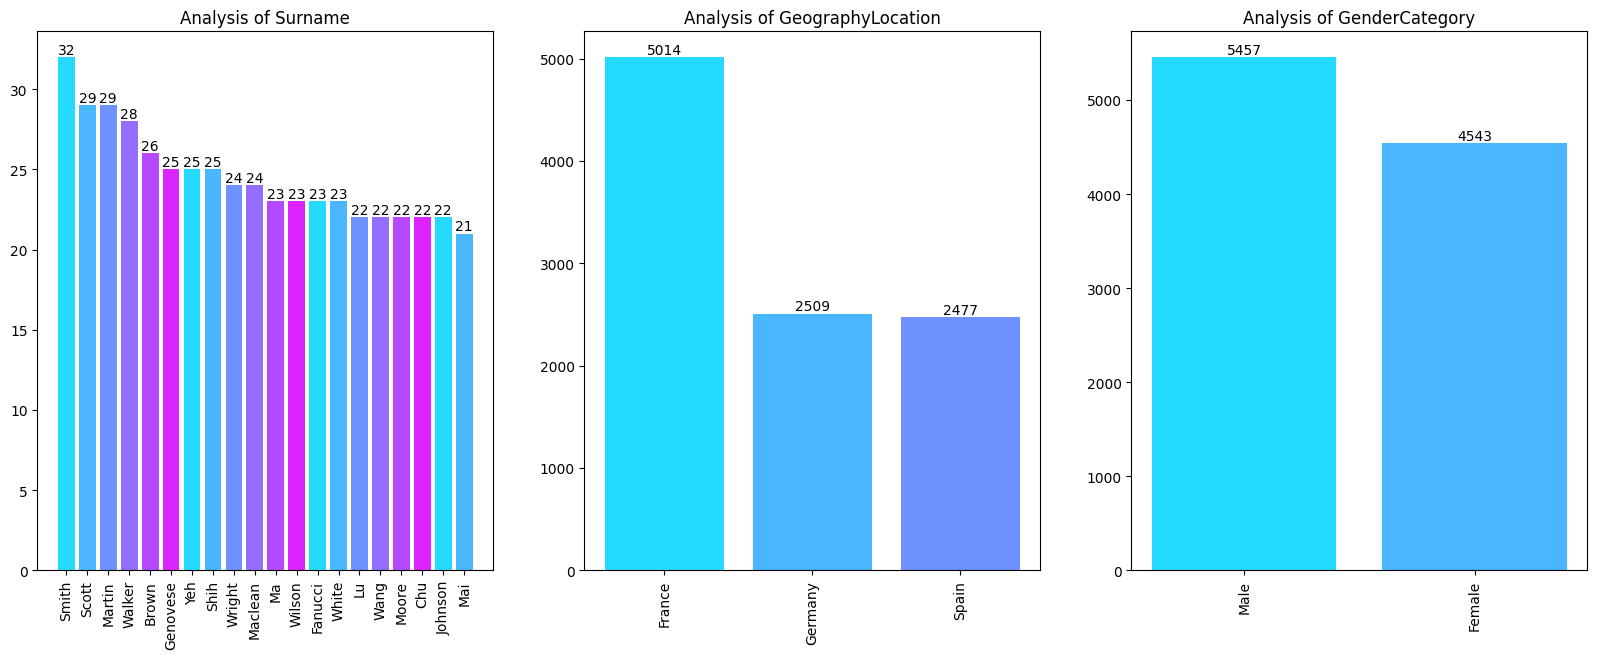

In [ ]:
# 3.13: Univariate Analysis
# means: single columns analysis
plt.figure(figsize = (20,7))
for i, j in enumerate(textual_columns):
    plt.subplot(1,3,i+1)
    temp_df = final_df[j].value_counts().head(20)
    x = temp_df.index
    y = temp_df.values
    plt.title(f"Analysis of {j}")
    ax = plt.bar(x,y, color = sns.color_palette('cool'))
    plt.bar_label(ax)
    plt.xticks(rotation = 90)/
plt.show()

# plt.show: out of loop hai
# subplot: plot multiple plots at once
# i: is index
# j: is column name
# enumerate: to get index and value at same time
# value_counts: to grouped data and count its value frequency
# sns.color_palette: to change color shades

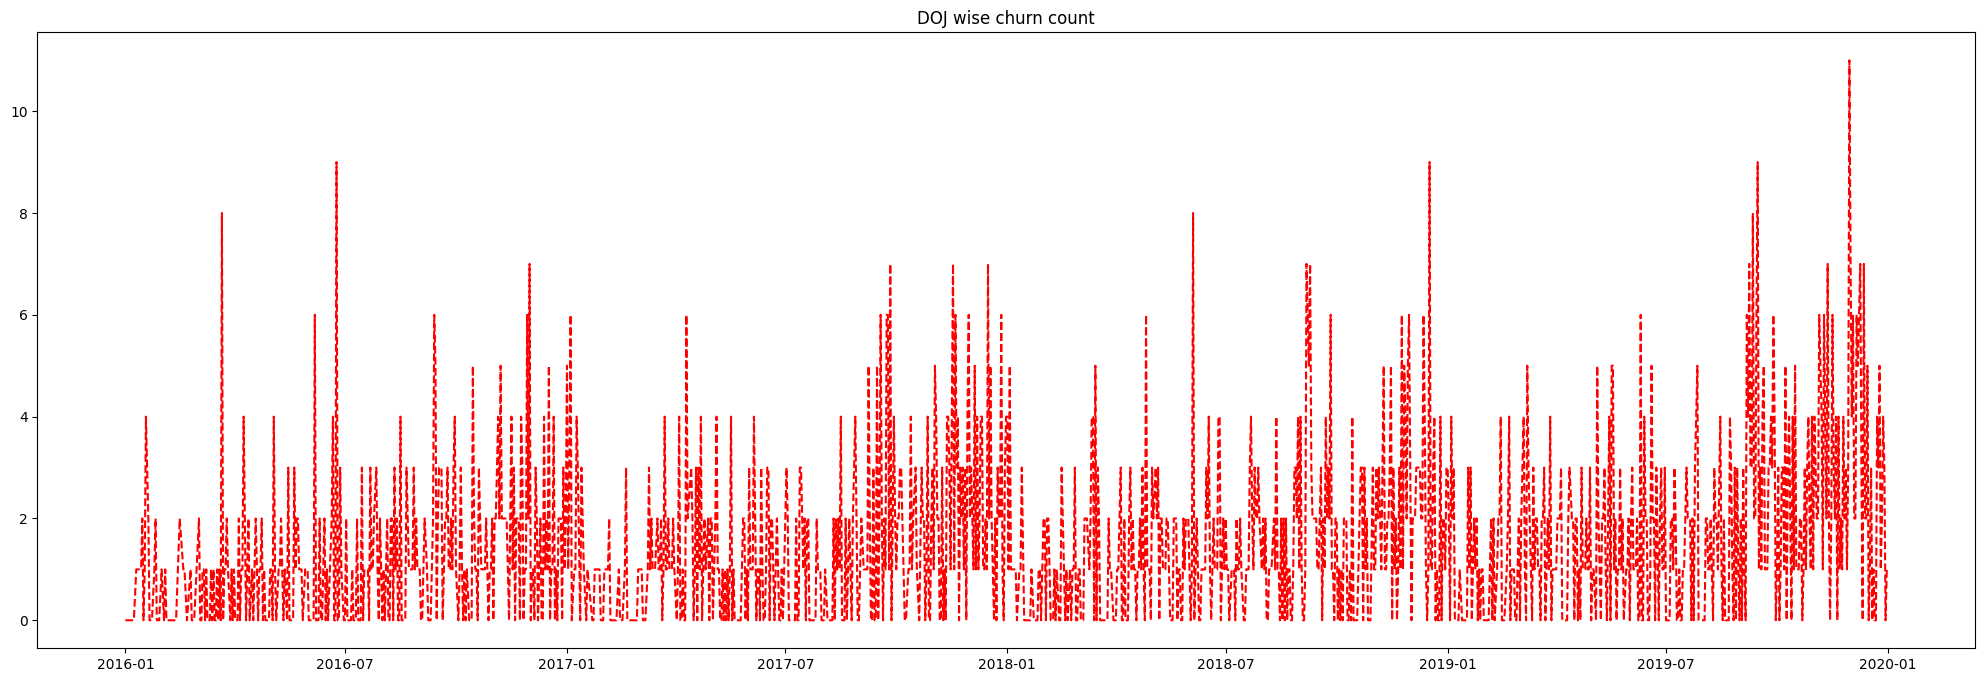

In [ ]:
# Step 3.14: Bivariate Analysis
# Show Bank DOJ wise churn count
plt.figure(figsize = (25,8))
plt.title("DOJ wise churn count")
temp_df = final_df.groupby ('Bank DOJ') ['Exited'].sum()
x = temp_df.index
y = temp_df.values
plt.plot(x,y, color = 'r', linestyle = '--')
plt.show()

In [ ]:
# Step 3.15: Create new column for monthly and weekly analysis
final_df['Month'] = final_df['Bank DOJ']. dt. month_name ()
final_df['Day'] = final_df['Bank DOJ'].dt.day_name ( )
# .dt: means: datetime
final_df.sample()

,CustomerId,CreditScore,GeographyID,GenderID,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Bank DOJ,Surname,GeographyLocation,GenderCategory,Month,Day
5255,15745533,799,1,2,63,5,110314.21,2,1,0,37464.0,1,2018-07-10,Sargent,France,Female,July,Tuesday


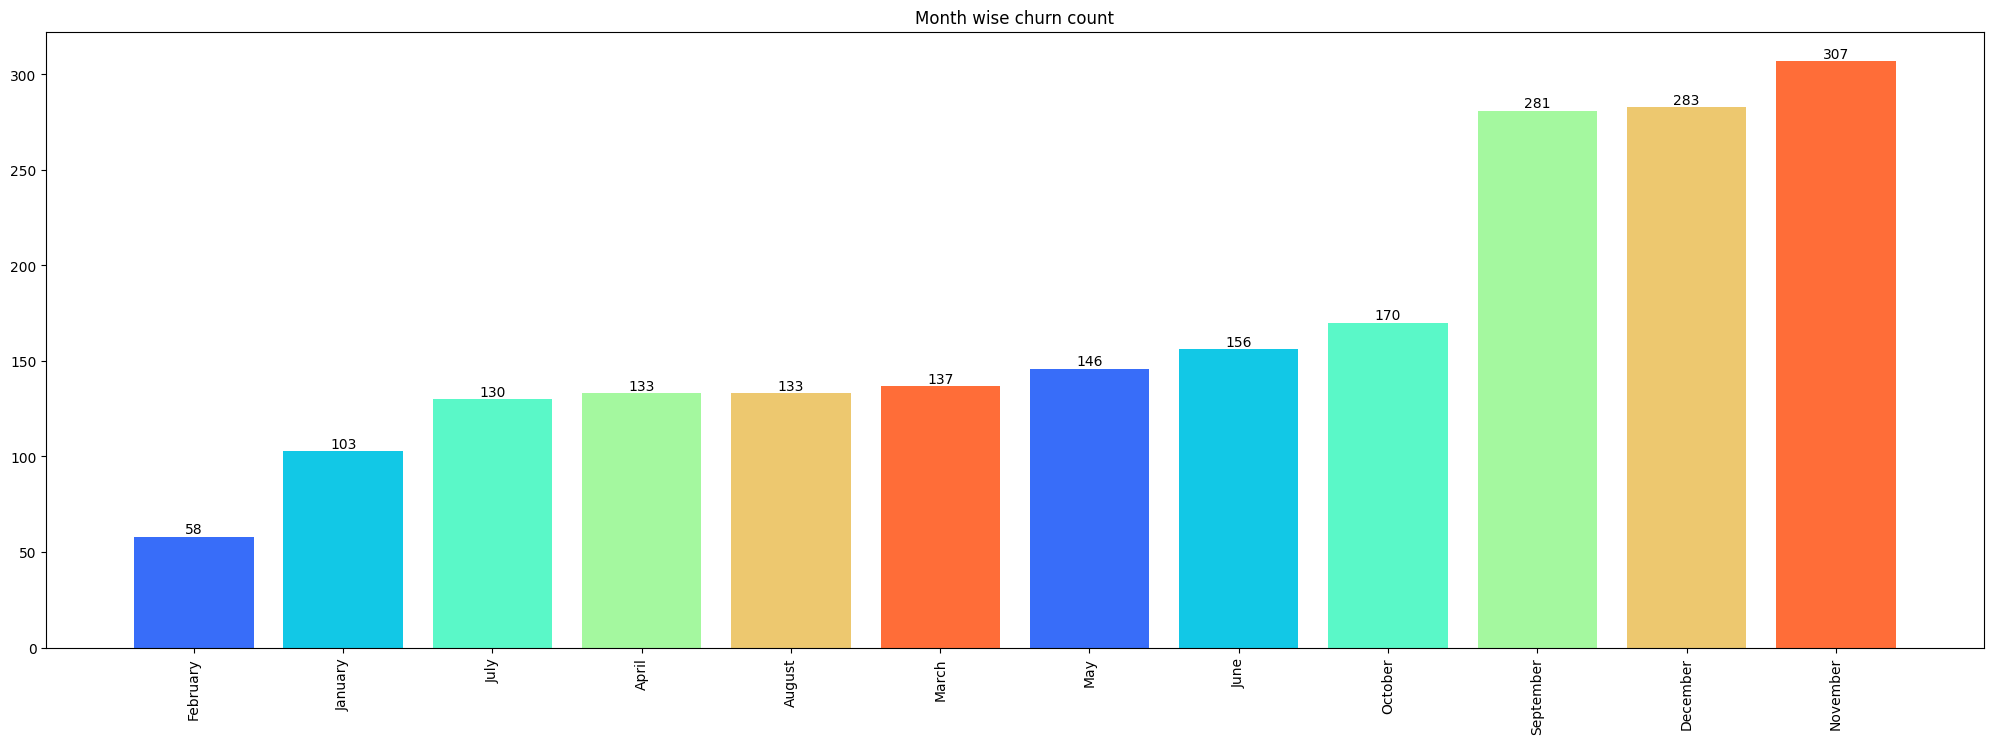

In [ ]:
# step 3.16:: Show Monthly Churn Analysis
plt.figure(figsize = (25,8))
plt.title("Month wise churn count")
temp_df = final_df.groupby('Month')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x,y,color = sns.color_palette('rainbow'))
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.show()

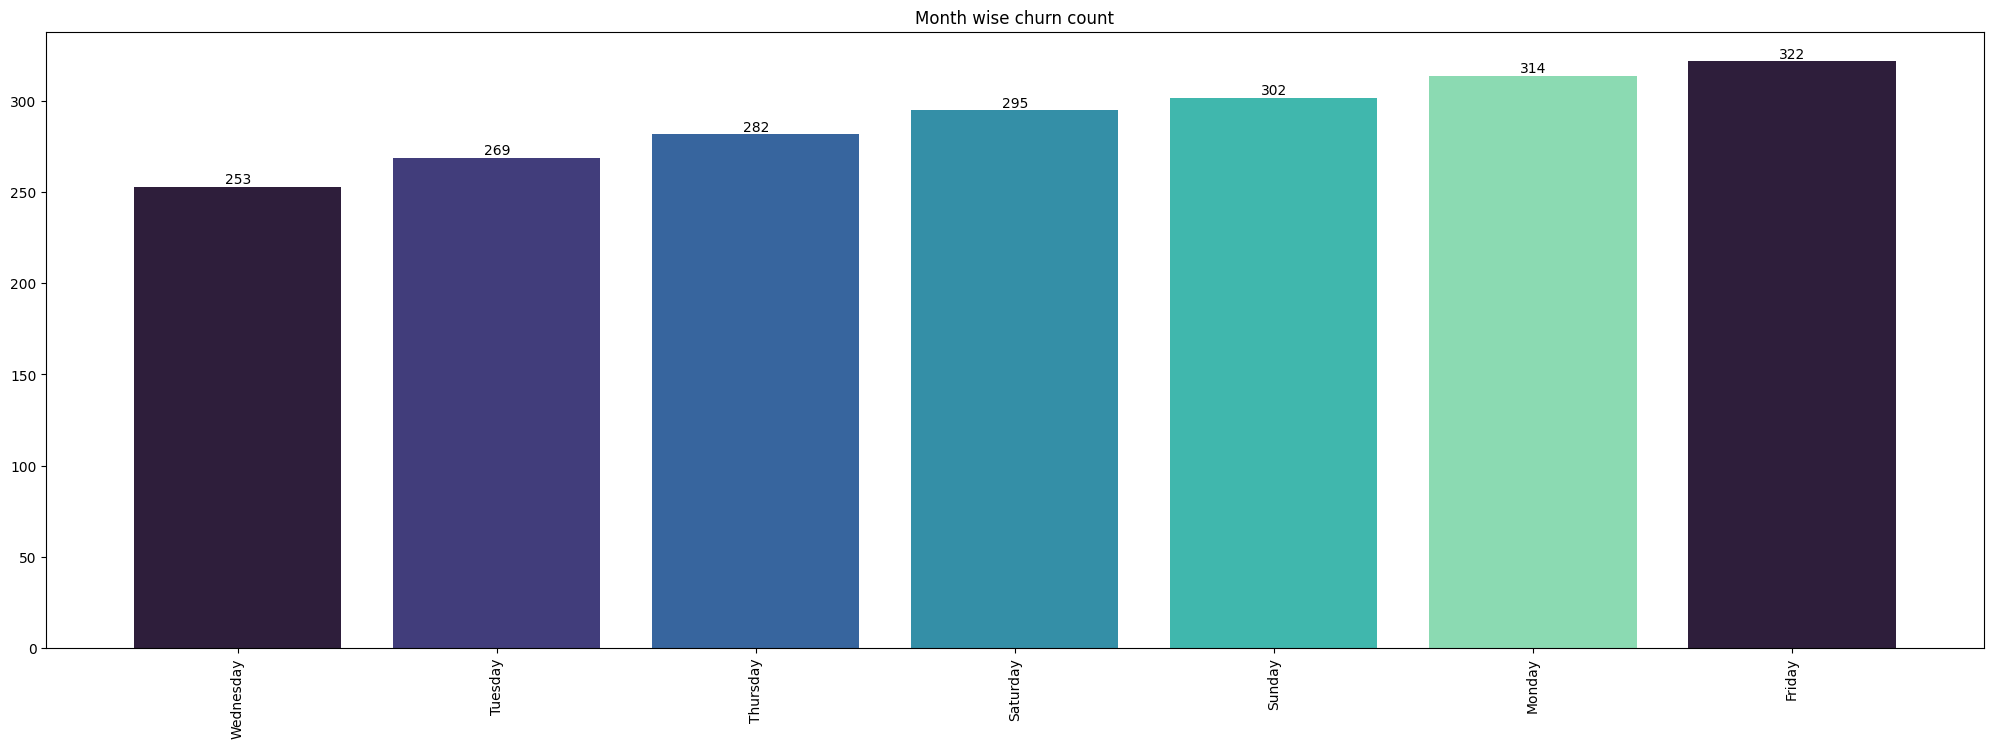

In [ ]:
# step 3.17:: Show Monthly Churn Analysis
plt.figure(figsize = (25,8))
plt.title("Month wise churn count")
temp_df = final_df.groupby('Day')['Exited'].sum().sort_values()
x = temp_df.index
y = temp_df.values
ax = plt.bar(x,y,color = sns.color_palette('mako'))
plt.bar_label(ax)
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# 3.18: gender wise Churn Analysis
# 3.19: GeographyLocation wise churn analysis
# 3.20: Tenure wise churn analysis

In [ ]:
#step 3.21: Remove unwanted cols for ML model
ml_drop_columns = ['CustomerId', 'GeographyID',
'GenderID', 'Bank DOJ',
'Surname', 'Day']
ml_df = final_df.drop(ml_drop_columns, axis = 1, inplace =
False)
ml_df.sample()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
2303,714,45,5,124693.48,1,0,1,187194.15,0,Spain,Male,December


Step 4: Feature Engineering

ML onlyworks with numerical data, if we are getting any textual data
we need to convert textual data to numerical
Technique is called feature engineering
Here GeographyLocation, GenderCategory or Month textual in nature

In [ ]:
# Types of technique
# OE: one hot encoding
# map: using dict
# apply lambda method
# categorical encoding
# get dummies
# ordinal encoding
# TF-IDF
# BOW: bag of words
# advance: countvectorizer, word embeddings
# more advance: vector database using cosine technique

In [ ]:
# Step 4.1

import calendar

months_name = list(calendar.month_name)[1:]
index = list(range(len(months_name)))
map = dict(zip(months_name, index))

ml_df['Month'] = ml_df['Month'].map(map)
ml_df.sample()

# zip: bind two objects together and give dict
# .map: method to map the key with value
#run only once


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
3424,688,42,4,0.0,2,0,0,197602.29,0,Spain,Male,NaN


In [ ]:
ml_df['GeographyLocation'].unique()


array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
ml_df['GenderCategory'] = ml_df['GenderCategory'].map({'Male': 0, 'Female': 1})

ml_df['GeographyLocation'] = ml_df['GeographyLocation'].map({
    'France': 0,
    'Spain': 1,
    'Germany': 2
})

ml_df.sample()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,GeographyLocation,GenderCategory,Month
7856,580,33,3,131647.01,2,0,0,79775.19,0,2,1,NaN


In [ ]:
# Step 4.2 Show target vs feature corr
ml_df.corr()['Exited'].sort_values(ascending=False)


,Exited
Exited,1.000000
Age,0.285323
GeographyLocation,0.153771
Balance,0.118533
GenderCategory,0.106512
EstimatedSalary,0.012097
Tenure,0.000699
HasCrCard,-0.007138
CreditScore,-0.027094
NumOfProducts,-0.047820


STEP 5 = DIVIDE DATA INTO FEATURES VS TARGET

In [ ]:
X = ml_df.drop('Exited', axis = 1)
y = ml_df['Exited']


# X: must be capital and in DataFrame
# y : must be small and in Series


print(X.shape)
print(y.shape)

(10000, 11)
(10000,)


STEP 6 = DIVIDE THE DATA INTO TRAIN AND TEST

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                   random_state=42,
                                                   test_size=0.2)

print("X_train-Shape: ", X_train.shape)
print("X_test-Shape: ", X_test.shape)
print("y_train-Shape: ", y_train.shape)
print("y_test-Shape: ", y_test.shape)

X_train-Shape:  (8000, 11)
X_test-Shape:  (2000, 11)
y_train-Shape:  (8000,)
y_test-Shape:  (2000,)
